In [1]:
pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [5]:
import yfinance as yf
import pandas as pd
import mplfinance as mpf
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from fredapi import Fred
import numpy as np

In [3]:
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [14]:
df = pd.read_csv("final_modeling_dataset.csv", index_col=0, parse_dates=True)
df.head()
print(df.shape)

(2566, 41)


In [15]:
# vix          → best single measure of market fear
# vix_ma_20    → smoothed VIX trend, filters daily noise
# yield_spread → recession signal, inverted = bear regime
# fedfunds     → monetary policy regime (easy vs tight)
# cpi_yoy      → inflation regime signal
# real_rate    → most powerful macro signal (negative = bull, positive = bear)
# return_1d    → current momentum direction
# volatility_20d → medium term volatility, identifies High-Vol regime

hmm_features = ["vix", "vix_ma_20", "yield_spread", "fedfunds", "cpi_yoy", "real_rate", "return_1d", "volatility_20d"]

#train and test split
train = df.loc["2015-01-01":"2024-12-31"].copy()
test  = df.loc["2025-01-01":"2025-12-31"].copy()

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

# Scale using training data only
X_train = train[hmm_features].values
X_test = test[hmm_features].values

#Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use KMeans to initialize HMM states more reliably
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans.fit(X_train_scaled)
kmeans_labels = kmeans.labels_

# Build initial means from KMeans centers
init_means = kmeans.cluster_centers_

# Fit HMM on training Data only using GaussianHMM
# n_components = 3 defines the number of hidden states. Whish is Bull, Bear and High Volatility
# covariance_type= full allows each state to have its own unique relationship between variables
hmm_model = GaussianHMM(n_components = 3, covariance_type ="diag", n_iter = 2000, random_state = 42, init_params="stc")

# Initialize means with KMeans centers
hmm_model.means_init = init_means

hmm_model.fit(X_train_scaled)
print(f"\nHMM converged: {hmm_model.monitor_.converged}")

# Predict regimes
train["regime_raw"] = hmm_model.predict(X_train_scaled)
test["regime_raw"] = hmm_model.predict(X_test_scaled)

df.loc[train.index, "regime_raw"] = train["regime_raw"]
df.loc[test.index, "regime_raw"] = test["regime_raw"]

#Identify which state is which regime
print("\nRegime Analysis (based on training data):")
print("=" * 50)
for state in range(3):
    subset = train[train["regime_raw"] == state]
    print(f"\nState {state}:")
    print(f"  Avg VIX:        {subset['vix'].mean():.2f}")
    print(f"  Avg Return:     {subset['return_1d'].mean():.4f}")
    print(f"  Avg Volatility: {subset['volatility_20d'].mean():.4f}")
    print(f"  Avg Yield Spread: {subset['yield_spread'].mean():.4f}")
    print(f"  Count:          {len(subset)} days") 

Train shape: (2317, 41)
Test shape:  (249, 41)

HMM converged: True

Regime Analysis (based on training data):

State 0:
  Avg VIX:        26.52
  Avg Return:     -0.0003
  Avg Volatility: 0.0160
  Avg Yield Spread: 0.1500
  Count:          639 days

State 1:
  Avg VIX:        15.61
  Avg Return:     0.0008
  Avg Volatility: 0.0066
  Avg Yield Spread: 1.0306
  Count:          848 days

State 2:
  Avg VIX:        15.02
  Avg Return:     0.0009
  Avg Volatility: 0.0071
  Avg Yield Spread: -0.0660
  Count:          830 days


The goal here was to teach the model what kind of market environment exists on any given day before asking it to predict returns. We used a Gaussian Hidden Markov Model with 3 hidden states fitted using the hmmlearn library. The HMM is unsupervised meaning it has no target variable, it simply looks at 8 macro and volatility features including VIX, yield spread, Fed Funds rate, real interest rate, and 20 day volatility and finds natural groupings in the data that represent distinct market conditions.

To avoid look-ahead bias the HMM was fitted exclusively on training data from January 2015 to December 2024 covering 2,317 trading days. The scaler was also fitted on training data only and then applied to the test period separately. The 2025 data containing 249 trading days was kept completely unseen during model fitting and only used for decoding regimes afterward. This ensures the regime labels assigned to 2025 reflect only patterns the model learned from the past.

In [29]:
#Map States to labels
state_map = {0 : "High_Vol", 1: "Bear", 2: "Bull"}

train["regime_label"] = train["regime_raw"].map(state_map)
test["regime_label"]  = test["regime_raw"].map(state_map)

df.loc[train.index, "regime_label"] = train["regime_label"]
df.loc[test.index,  "regime_label"] = test["regime_label"]

print("\nTrain Regime Distribution:")
print(train["regime_label"].value_counts())
print(f"\nBull %:     {(train['regime_label'] == 'Bull').mean()*100:.1f}%")
print(f"Bear %:     {(train['regime_label'] == 'Bear').mean()*100:.1f}%")
print(f"High-Vol %: {(train['regime_label'] == 'High_Vol').mean()*100:.1f}%")

print("\nTest Regime Distribution:")
print(test["regime_label"].value_counts())

df.to_csv("processed_data_with_regimes.csv", index=True)
demo = pd.read_csv("processed_data_with_regimes.csv")
demo.head(5)


Train Regime Distribution:
regime_label
Bear        848
Bull        830
High_Vol    639
Name: count, dtype: int64

Bull %:     35.8%
Bear %:     36.6%
High-Vol %: 27.6%

Test Regime Distribution:
regime_label
Bull        196
High_Vol     52
Bear          1
Name: count, dtype: int64


,Date,Open,High,Low,Close,Volume,adj_close,return_1d,target,return_5d,...,fedfunds,cpi,yield_spread,vix_change,cpi_yoy,real_rate,yield_spread_change,vix_ma_20,regime_raw,regime_label
0,2015-10-16,2024.369995,2033.540039,2020.459961,2033.109985,3595430000,2033.109985,0.004570,1,0.009043,...,0.12,237.733,1.43,-0.062305,0.001276,-0.007617,0.00,20.4530,1.0,Bear
1,2015-10-19,2031.729980,2034.449951,2022.310059,2033.660034,3287320000,2033.660034,0.000271,0,0.008030,...,0.12,237.733,1.43,-0.004651,0.001276,-0.007617,0.00,20.1950,1.0,Bear
2,2015-10-20,2033.130005,2039.119995,2026.609985,2030.770020,3331500000,2030.770020,-0.001421,0,0.013515,...,0.12,237.733,1.42,0.051402,0.001276,-0.007617,-0.01,19.8605,1.0,Bear
3,2015-10-21,2033.469971,2037.969971,2017.219971,2018.939941,3627790000,2018.939941,-0.005825,1,0.012386,...,0.12,237.733,1.40,0.060317,0.001276,-0.007617,-0.02,19.5890,1.0,Bear
4,2015-10-22,2021.880005,2055.199951,2021.880005,2052.510010,4430850000,2052.510010,0.016628,1,0.014156,...,0.12,237.733,1.43,-0.134731,0.001276,-0.007617,0.03,19.1380,1.0,Bear


The model identified three distinct hidden states. The Bull regime captured calm trending markets with the lowest average VIX around 15, positive daily returns, and low volatility. The Bear regime represented stressed but not panicked markets with moderate VIX and near zero returns. The High_Vol regime captured genuinely chaotic periods with VIX averaging above 26, negative average returns, and volatility more than double the Bull regime.

In [17]:
print("Train Regime Summary:")
train_summary = train.groupby("regime_label").agg(
    avg_return=("return_1d", "mean"),
    avg_volatility=("volatility_20d", "mean"),
    avg_vix=("vix", "mean"),
    avg_yield_spread=("yield_spread", "mean"),
    count=("regime_label", "count")
)

print(train_summary)

print("\nTest Regime Summary:")
test_summary = test.groupby("regime_label").agg(
    avg_return=("return_1d", "mean"),
    avg_volatility=("volatility_20d", "mean"),
    avg_vix=("vix", "mean"),
    avg_yield_spread=("yield_spread", "mean"),
    count=("regime_label", "count")
)

print(test_summary)

Train Regime Summary:
              avg_return  avg_volatility    avg_vix  avg_yield_spread  count
regime_label                                                                
Bear            0.000798        0.006615  15.605094          1.030578    848
Bull            0.000865        0.007082  15.022964         -0.065964    830
High_Vol       -0.000279        0.016010  26.520970          0.150000    639

Test Regime Summary:
              avg_return  avg_volatility    avg_vix  avg_yield_spread  count
regime_label                                                                
Bear           -0.002224        0.009172  17.930000          0.320000      1
Bull            0.000687        0.007450  17.222551          0.495459    196
High_Vol        0.000846        0.019891  25.611154          0.433077     52


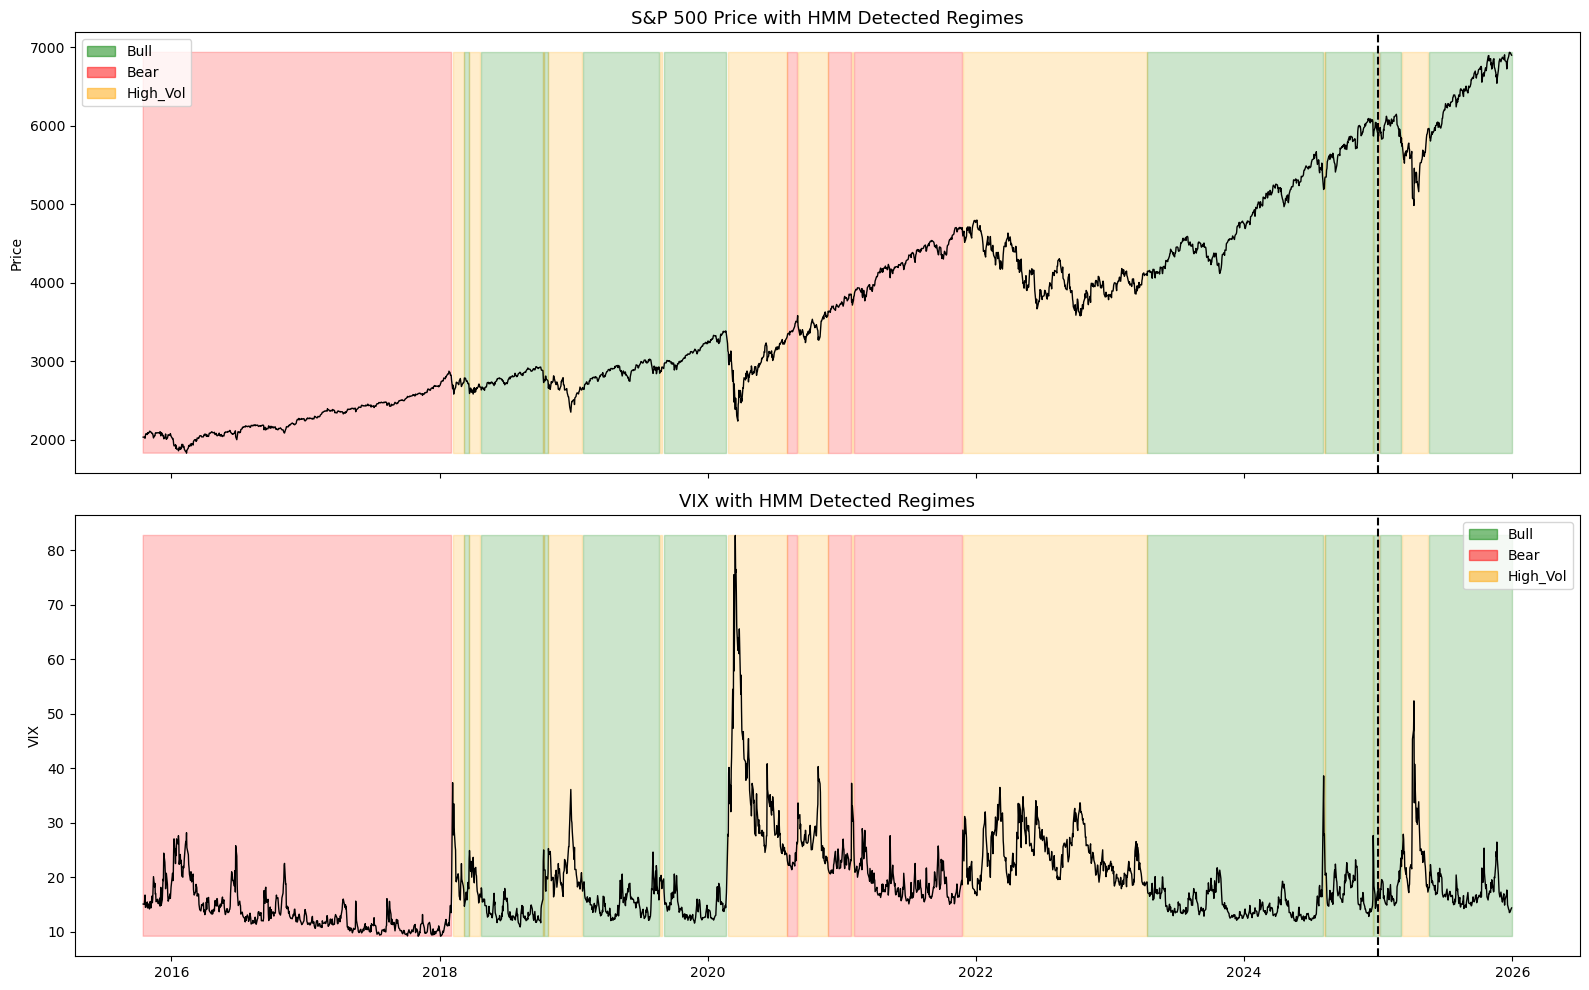

In [18]:
#Visualization 
colors = {"Bull":     "green", "Bear":     "red", "High_Vol": "orange"}

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Chart 1: Price with regime shading
axes[0].plot(df.index, df["adj_close"], color="black", linewidth=1, zorder=2)
for regime, color in colors.items():
    mask = df["regime_label"] == regime
    axes[0].fill_between(
        df.index,
        df["adj_close"].min(),
        df["adj_close"].max(),
        where=mask,
        alpha=0.2,
        color=color
    )
patches = [mpatches.Patch(color=c, alpha=0.5, label=r) for r, c in colors.items()]
axes[0].legend(handles=patches, loc="upper left")
axes[0].set_title("S&P 500 Price with HMM Detected Regimes", fontsize=13)
axes[0].set_ylabel("Price")
axes[0].axvline(pd.Timestamp("2025-01-01"), color="black",
                linewidth=1.5, linestyle="--", label="Train/Test Split")

# Chart 2: VIX with regime shading
axes[1].plot(df.index, df["vix"], color="black", linewidth=1, zorder=2)
for regime, color in colors.items():
    mask = df["regime_label"] == regime
    axes[1].fill_between(
        df.index,
        df["vix"].min(),
        df["vix"].max(),
        where=mask,
        alpha=0.2,
        color=color
    )
axes[1].axvline(pd.Timestamp("2025-01-01"), color="black",
                linewidth=1.5, linestyle="--", label="Train/Test Split")
axes[1].set_title("VIX with HMM Detected Regimes", fontsize=13)
axes[1].set_ylabel("VIX")
axes[1].legend(handles=patches, loc="upper right")

plt.tight_layout()
plt.show()


The chart validates the model well. Green Bull periods cluster strongly around the 2019 pre-COVID rally and the powerful 2023 to 2024 recovery. The orange High_Vol shading appears precisely where you would expect it around the COVID crash in early 2020 and during the 2022 rate hike selloff when VIX repeatedly spiked above 30. The 2025 test period shows mostly Bear and High_Vol which accurately reflects the tariff shock and Fed uncertainty that defined early 2025. The regime label now becomes a direct input feature for the return prediction model in the next stage.